In [ ]:
import torch
import transformers
import pretty_midi
import librosa

All good!


In [13]:
import pandas as pd

# Load NRC VAD Lexicon
vad_df = pd.read_csv('../data/NRC_VAD/NRC-VAD-Lexicon.txt', sep='\t', header=0)

# Preview
print(vad_df.head())
print(f"Total words: {len(vad_df)}")

         term  valence  arousal  dominance
0   a battery    0.134   -0.298     -0.096
1       a bit   -0.096   -0.264     -0.214
2     a bunch    0.088   -0.350     -0.068
3  a cappella    0.134   -0.116     -0.200
4    a couple    0.266   -0.110      0.090
Total words: 54801


In [17]:
def get_vad(sentence):
    words = sentence.split()
    vad_values = []
    
    for word in words:
        row = vad_df[vad_df['term'] == word]
        if not row.empty:
            valence = row['valence'].values[0]
            arousal = row['arousal'].values[0]
            dominance = row['dominance'].values[0]
            vad_values.append((valence, arousal, dominance))
    
    if vad_values:
        avg_valence = sum(v[0] for v in vad_values) / len(vad_values)
        avg_arousal = sum(v[1] for v in vad_values) / len(vad_values)
        avg_dominance = sum(v[2] for v in vad_values) / len(vad_values)
        return avg_valence, avg_arousal, avg_dominance
    else:
        return None
    

# Test
result = get_vad("I feel fresh and energetic")
print(result)

(np.float64(0.5285), np.float64(0.131), np.float64(0.20850000000000002))


In [20]:
import pretty_midi
import os

# Load one MIDI file
midi_files = os.listdir('../data/emopia/')
sample_file = midi_files[0]

midi = pretty_midi.PrettyMIDI(f'../data/emopia/midis/Q1__8v0MFBZoco_0.mid')

print(f"File: {sample_file}")
print(f"Tempo: {midi.estimate_tempo():.1f} BPM")
print(f"Duration: {midi.get_end_time():.1f} seconds")
print(f"Total notes: {sum(len(i.notes) for i in midi.instruments)}")

File: .DS_Store
Tempo: 234.8 BPM
Duration: 60.0 seconds
Total notes: 627


In [21]:
import pretty_midi
import os

# Filter only MIDI files
midi_files = [f for f in os.listdir('../data/emopia/midis/') if f.endswith('.mid')]

sample_file = midi_files[0]
midi = pretty_midi.PrettyMIDI(f'../data/emopia/midis/Q1__8v0MFBZoco_0.mid')

print(f"File: {sample_file}")
print(f"Tempo: {midi.estimate_tempo():.1f} BPM")
print(f"Duration: {midi.get_end_time():.1f} seconds")
print(f"Total notes: {sum(len(i.notes) for i in midi.instruments)}")

File: Q1_0vLPYiPN7qY_0.mid
Tempo: 234.8 BPM
Duration: 60.0 seconds
Total notes: 627


In [22]:
import os

midi_files = [f for f in os.listdir('../data/emopia/midis/') if f.endswith('.mid')]

q1 = [f for f in midi_files if f.startswith('Q1')]
q2 = [f for f in midi_files if f.startswith('Q2')]
q3 = [f for f in midi_files if f.startswith('Q3')]
q4 = [f for f in midi_files if f.startswith('Q4')]

print(f"Q1 Happy    → {len(q1)} files")
print(f"Q2 Angry    → {len(q2)} files")
print(f"Q3 Sad      → {len(q3)} files")
print(f"Q4 Peaceful → {len(q4)} files")
print(f"Total       → {len(midi_files)} files")

Q1 Happy    → 250 files
Q2 Angry    → 265 files
Q3 Sad      → 253 files
Q4 Peaceful → 310 files
Total       → 1078 files


In [23]:
import pretty_midi
import pandas as pd

def extract_midi_stats(file_path):
    midi = pretty_midi.PrettyMIDI(file_path)
    notes = [note for inst in midi.instruments for note in inst.notes]
    
    if not notes:
        return None
    
    return {
        'tempo'    : round(midi.estimate_tempo(), 1),
        'duration' : round(midi.get_end_time(), 1),
        'avg_pitch'    : round(sum(n.pitch for n in notes) / len(notes), 1),
        'avg_velocity' : round(sum(n.velocity for n in notes) / len(notes), 1),
        'note_count'   : len(notes)
    }

# Run on all files
rows = []
for f in midi_files:
    emotion = f[:2]  # Q1, Q2, Q3, Q4
    stats = extract_midi_stats(f'../data/emopia/midis/{f}')
    if stats:
        stats['emotion'] = emotion
        rows.append(stats)

df = pd.DataFrame(rows)
print(df.groupby('emotion').mean().round(2))

          tempo  duration  avg_pitch  avg_velocity  note_count
emotion                                                       
Q1       206.41     35.09      62.58         77.32      296.13
Q2       207.42     39.31      60.31         78.69      386.24
Q3       176.48     43.64      63.46         54.40      200.44
Q4       178.94     41.33      61.16         53.00      188.84


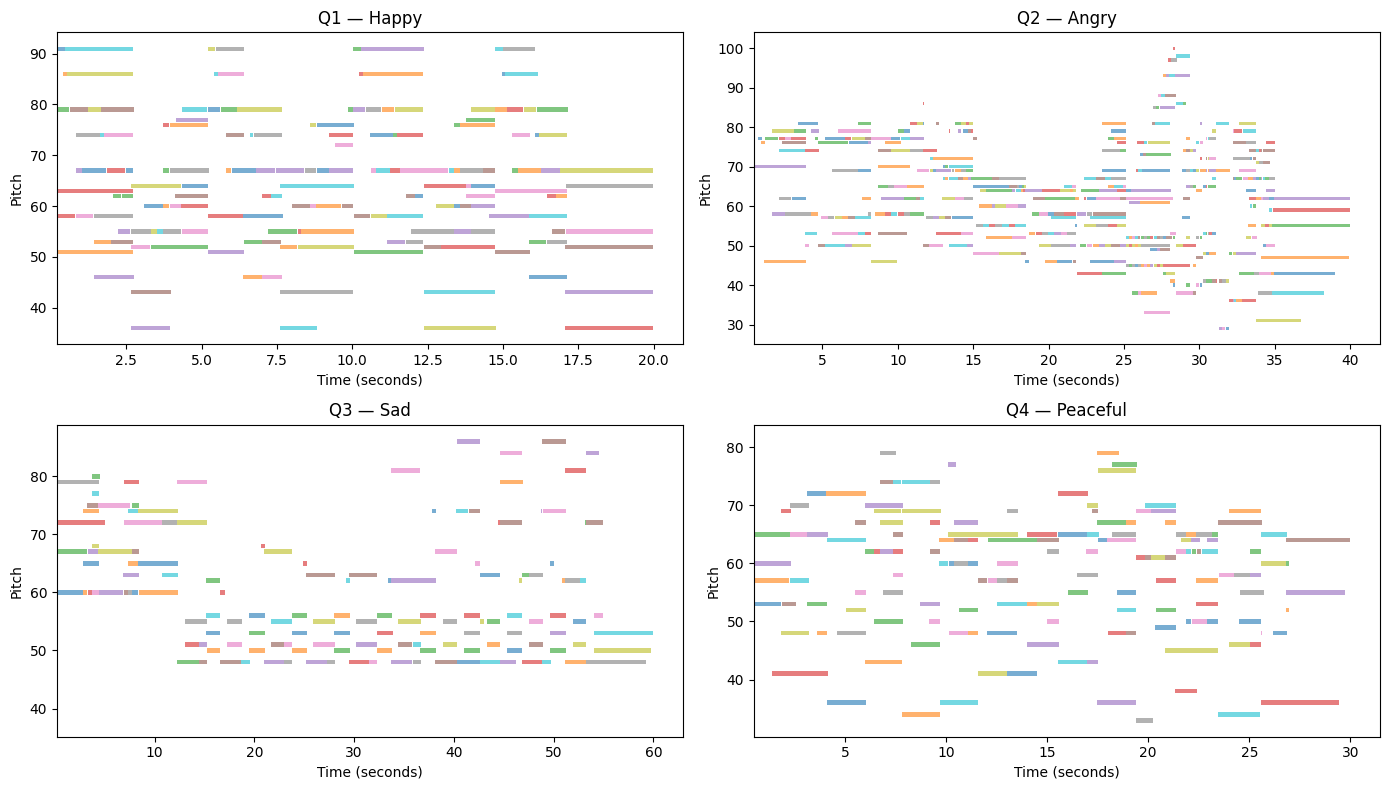

In [24]:
import pretty_midi
import matplotlib.pyplot as plt

emotions = {'Q1': 'Happy', 'Q2': 'Angry', 'Q3': 'Sad', 'Q4': 'Peaceful'}
files = {'Q1': q1[0], 'Q2': q2[0], 'Q3': q3[0], 'Q4': q4[0]}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, (q, label) in enumerate(emotions.items()):
    midi = pretty_midi.PrettyMIDI(f'../data/emopia/midis/{files[q]}')
    notes = [note for inst in midi.instruments for note in inst.notes]
    
    for note in notes:
        axes[idx].barh(note.pitch, note.end - note.start,
                       left=note.start, height=0.8, alpha=0.6)
    
    axes[idx].set_title(f'{q} — {label}')
    axes[idx].set_xlabel('Time (seconds)')
    axes[idx].set_ylabel('Pitch')

plt.tight_layout()

plt.show()